In [19]:
# conda activate chronocell

import os
import sys
import shap
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import mean_squared_error, r2_score

sys.path.append(os.path.abspath("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/simulations/code"))

from protein_from_RNA import *

Some refs for getting reverse time Markov generator:

https://www.randomservices.org/random/markov/TimeReversal2.html
 
https://link.springer.com/book/10.1007/978-1-4612-3038-0 (p. 239)

In [ ]:
# ==== Transcription rate ====
alpha_mu = 2 # (Corresponds to ~7 mRNAs/hour, per Chronocell paper)
alpha_sd = 1

# === Splicing rate ===
beta_mu = 2 # np.log(splicing_rate) # (Corresponds to ~8.5 minute splicing rate, per Chronocell paper)
beta_sd = 0.5

# === mRNA degradation rate ===
gamma_mu = 0.5 # (Corresponds to ~2.8 hour half-life, per Chronocell paper)
gamma_sd = 0.5

# Simulate data

random_seed = 666 
n = 100 # No. cells per lineage
p = 4 # No. genes
topo = np.array([[0, 1, 2, 3]])
tau = (0, 2, 6, 8)

theta = get_RNA_params(topo, p, alpha_mu, alpha_sd, beta_mu, beta_sd, gamma_mu, gamma_sd, random_seed=random_seed)
Y_observed, Y, theta, rd, true_t, true_l = simulate_RNA(topo, tau, theta, n, random_seed=random_seed)

In [ ]:
# t = true_t
# theta_ = theta[0].copy()
# a0 = theta_[0] # Starting RNA abundance 
# a = theta_[1:len(topo.flatten())] 
# beta = theta_[-2] # Splicing rate
# alpha = a * beta # These values are divided by splicing rate; removing this factor now
# gamma = theta_[-1] # Degradation rate

In [ ]:
# tate_grid = np.searchsorted(tau, t, side="right") - 1 
# alpha_per_t = alpha[state_grid]

In [ ]:
# np.save("toy_data/alpha.npy", alpha)
# np.save("toy_data/alpha_per_t.npy", alpha_per_t)
# np.save("toy_data/beta.npy", beta)
# np.save("toy_data/gamma.npy", gamma)
# np.save("toy_data/t.npy", true_t)
# np.save("toy_data/lambda_U.npy", Y[:, :, 0])
# np.save("toy_data/lambda_S.npy", Y[:, :, 1])
# np.save("toy_data/tau.npy", tau)


In [5]:
gene_idx = 4

# Plot example RNA trajectory

plt.scatter(true_t, Y[:, gene_idx, 1])
plt.scatter(true_t, Y_observed[:, gene_idx, 1], s=.5, color="gray")

plt.xlabel("Time (hours)");
plt.ylabel("# spliced RNA molecules")
plt.title(f"Spliced RNA abundance over time (gene {gene_idx})");

IndexError: index 4 is out of bounds for axis 1 with size 1

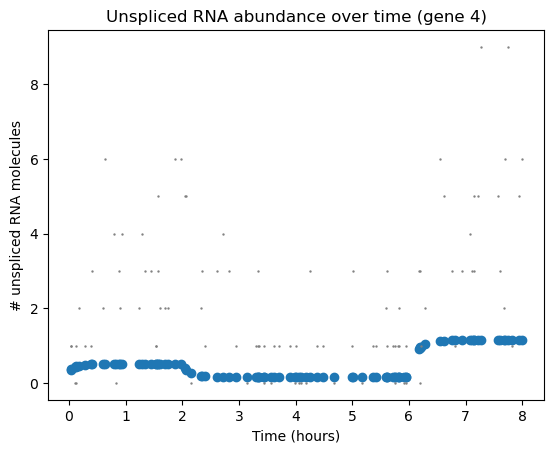

In [ ]:
plt.scatter(true_t, Y[:, gene_idx, 0])
plt.scatter(true_t, Y_observed[:, gene_idx, 1], s=.5, color="gray")

plt.xlabel("Time (hours)");
plt.ylabel("# unspliced RNA molecules")
plt.title(f"Unspliced RNA abundance over time (gene {gene_idx})");

In [ ]:
cell_idx = np.argmax(true_t)
print(Y[cell_idx, gene_idx, 0])
print(Y[cell_idx, gene_idx, 1])

1.1409775197195768
5.899196865783884


In [ ]:
t = true_t
theta_ = theta.copy()
a0 = theta_[gene_idx, 0] # Starting RNA abundance 
a = theta_[gene_idx, 1:len(topo.flatten())] 
beta = theta_[gene_idx, -2] # Splicing rate
alpha = a * beta # These values are divided by splicing rate; removing this factor now
gamma = theta_[gene_idx, -1] # Degradation rate
state_grid = np.searchsorted(tau, t, side="right") - 1 # Right closed convention τ_j < t_i ≤ τ_{j+1} (per Chronocell model)

In [8]:
# Backwards recursion

def backward_step(U_curr, S_curr, alpha, beta, gamma, dt):
    eB = np.exp(-beta * dt)
    eG = np.exp(-gamma * dt)
    one_minus_eB_over_beta  = -np.expm1(-beta  * dt) / beta
    one_minus_eG_over_gamma = -np.expm1(-gamma * dt) / gamma
    d = (gamma - beta)
    cross = np.where(
        np.abs(d) > 0,
        np.exp(-gamma * dt) * (np.expm1(d * dt) / d),
        dt * np.exp(-gamma * dt)
    )
    U_prev = (U_curr - alpha * one_minus_eB_over_beta) / eB
    S_prev = (S_curr - beta * cross * U_prev - alpha * (one_minus_eG_over_gamma - cross)) / eG
    
    return U_prev, S_prev 

In [34]:
# Step by step recursion

U = np.full(len(t), np.nan, dtype=float)
S = np.full(len(t), np.nan, dtype=float)
idxT = len(t) - 1

U[idxT] = Y[idxT, gene_idx, 0]
S[idxT] = Y[idxT, gene_idx, 1]

for k in reversed(range(1, idxT + 1)):
    t_prev, t_curr = t[k-1], t[k]
    state_prev, state_curr = state_grid[k-1], state_grid[k]
    
    if state_prev == state_curr:
        dt = t_curr - t_prev
        alpha_k = alpha[state_curr]
        U[k-1], S[k-1] = backward_step(U[k], S[k], alpha_k, beta, gamma, dt)
    else:
        # State switch happens in current interval
        tau_c = tau[state_curr]
        
        # Split backward march into 2 steps
        # Interval 2: (tau, t_k]
        dt2 = t_curr - tau_c
        U_mid, S_mid = backward_step(U[k], S[k], alpha[state_curr], beta, gamma, dt2)
        
        # Interval 1: (t_k-1, tau]
        dt1 = tau_c - t_prev
        U[k-1], S[k-1] = backward_step(U_mid, S_mid, alpha[state_prev], beta, gamma, dt1)
        
        
print(f"From [{t[idxT]}, {t[0]})") 
print("")
print(f"Prediction for t = {t[0]}:\n", U[0], S[0])
print(f"Simulated for t = {t[0]}:\n", Y[0, gene_idx, 0], Y[0, gene_idx, 1])

From [7.990357382093538, 0.03127875094221988)

Prediction for t = 0.03127875094221988:
 -1630756042650.021 1996126226758.1057
Simulated for t = 0.03127875094221988:
 0.3514515918449692 1.6745749866552664


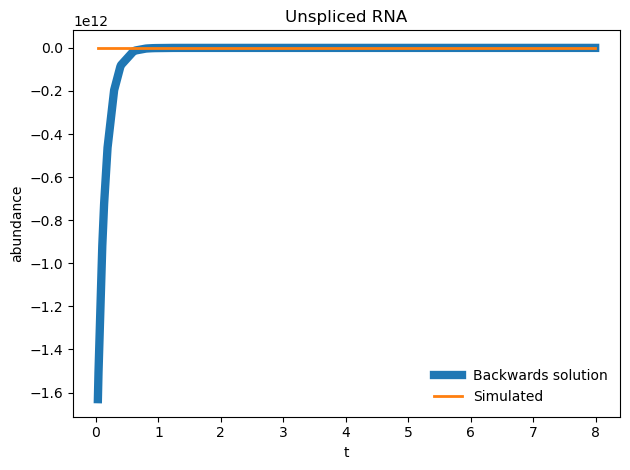

In [35]:
fig, ax = plt.subplots()

ax.plot(t, U, label='Backwards solution', linewidth=6)              # thicker line
ax.plot(t, Y[:, gene_idx, 0], label='Simulated', linewidth=2)

ax.set_title("Unspliced RNA")
ax.set_xlabel('t')
ax.set_ylabel('abundance')
ax.legend(frameon=False)
plt.tight_layout()

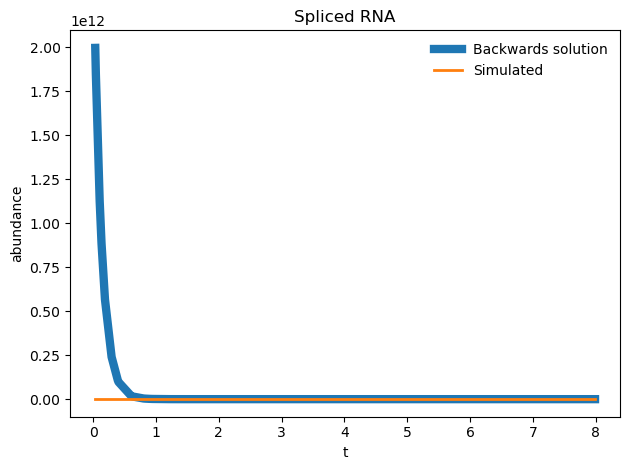

In [36]:
fig, ax = plt.subplots()

ax.plot(t, S, label='Backwards solution', linewidth=6)              # thicker line
ax.plot(t, Y[:, gene_idx, 1], label='Simulated', linewidth=2)

ax.set_title("Spliced RNA")
ax.set_xlabel('t')
ax.set_ylabel('abundance')
ax.legend(frameon=False)
plt.tight_layout()

In [10]:
# Jumping multiple steps

U = np.full(len(t), np.nan, dtype=float)
S = np.full(len(t), np.nan, dtype=float)

idxT = len(t) - 1

U[idxT] = Y[idxT, gene_idx, 0]
S[idxT] = Y[idxT, gene_idx, 1]

k = idxT
n_steps = 13
t_prev, t_curr = t[k-n_steps], t[k]
state_prev, state_curr = state_grid[k-n_steps], state_grid[k]
alpha_k = alpha[state_curr]

print(f"Starting prediction for t = {t_curr}:\n", U[k], S[k])
print(f"Starting simulated for t = {t_curr}:\n", Y[k, gene_idx, 0], Y[k, gene_idx, 1])
print("")
print("---------")
print("")

if state_prev == state_curr:
    dt = t_curr - t_prev
    U[k-1], S[k-1] = backward_step(U[k], S[k], alpha_k, beta, gamma, dt)
    print(f"From [{t_curr}, {t_prev})") 
    print(f"Prediction for t = {t_prev}:\n", U[k-1], S[k-1])
    print(f"Simulated for t = {t_prev}:\n", Y[k-1, gene_idx, 0], Y[k-1, gene_idx, 1])
    
else:
    # State switch happens over interval (t_prev, t_curr]
    tau_c = tau[state_curr]
    dt = t_curr - tau_c 
    U_mid, S_mid = backward_step(U[k], S[k], alpha_k, beta, gamma, dt)
   
    step_idx = np.searchsorted(t, tau_c) # Time associated with state switch in simulated values
    print(f"From [{t_curr}, {tau_c})") 
    print(f"Prediction for t = {tau_c}:\n", U_mid, S_mid)
    print(f"Simulated for t = {tau_c}:\n", Y[step_idx, gene_idx, 0], Y[step_idx, gene_idx, 1])
    print("\n")
    
    if (state_curr - state_prev) > 1:
        # If more than two switch points are crossed
        for state_mid in reversed(range(state_prev + 1, state_curr)):
            tau_mid = tau[state_mid]
            tau_left = tau[state_mid - 1]
            dt = tau_left - tau_mid # t_curr - tau_mid
            alpha_k = alpha[state_mid]
            U_mid, S_mid = backward_step(U_mid, S_mid, alpha_k, beta, gamma, dt)

            step_idx = np.searchsorted(t, tau_left) # Time associated with state switch in simulated values
            print(f"From [{tau_mid}, {t[tau_left]})")
            print(f"Prediction for t = {tau_left}:\n", U_mid, S_mid)
            print(f"Simulated for t = {tau_left}:\n", Y[step_idx, gene_idx, 0], Y[step_idx, gene_idx, 1])
            print("\n")
            
        tau_c = tau_mid
        
    dt = tau_c - t_prev
    alpha_k = alpha[state_prev]
    U[k-1], S[k-1] = backward_step(U_mid, S_mid, alpha_k, beta, gamma, dt)
    
    step_idx = np.searchsorted(t, tau_c) # Time associated with state switch in simulated values
    print(f"From [{tau_c}, {t_prev})")
    print(f"Prediction for t = {t_prev}:\n", U[k-1], S[k-1])
    print(f"Simulated for t = {t_prev}:\n", Y[step_idx, gene_idx, 0], Y[step_idx, gene_idx, 1])

Starting prediction for t = 7.990357382093538:
 1.1409775197195768 5.899196865783884
Starting simulated for t = 7.990357382093538:
 1.1409775197195768 5.899196865783884

---------

From [7.990357382093538, 7.072204838072818)
Prediction for t = 7.072204838072818:
 1.1408207570674962 4.919809103262665
Simulated for t = 7.072204838072818:
 1.1409774702426594 5.87094705984124


In [ ]:
# Forward recursion:

def forward_step_const_alpha(U_prev, S_prev, alpha, beta, gamma, dt):
    eB = np.exp(-beta * dt)
    eG = np.exp(-gamma * dt)
    one_minus_eB_over_beta  = -np.expm1(-beta  * dt) / beta
    one_minus_eG_over_gamma = -np.expm1(-gamma * dt) / gamma
    d = (gamma - beta)
    cross = np.where(np.abs(d) > 0,
                     np.exp(-gamma * dt) * (np.expm1(d * dt) / d),
                     dt * np.exp(-gamma * dt))
    U = eB * U_prev + alpha * one_minus_eB_over_beta
    S = eG * S_prev + beta * cross * U_prev + alpha * (one_minus_eG_over_gamma - cross)
    return U, S

idxT = len(t) - 1
U = np.full(len(t), np.nan, dtype=float)
S = np.full(len(t), np.nan, dtype=float)
U[0] = (Y[0, gene_idx, 0]) # Initialize with starting RNA abundance at t0
S[0] = (Y[0, gene_idx, 1])

for k in range(1, len(t)):
    U_prev = U[k-1]
    S_prev = S[k-1]
    state_curr = state_grid[k]
    t_prev, t_cur = t[k-1], t[k]
    s_prev = np.searchsorted(tau, t_prev, side='right') - 1
    s_cur  = np.searchsorted(tau, t_cur, side='right') - 1
    if s_prev == s_cur:
        U[k], S[k] = forward_step_const_alpha(U_prev, S_prev, alpha[s_cur], beta, gamma, t_cur - t_prev)
    else:
        tau_c = tau[s_cur]
        U_mid, S_mid = forward_step_const_alpha(U_prev, S_prev, alpha[s_prev], beta, gamma, tau_c - t_prev)
        U[k], S[k] = forward_step_const_alpha(U_mid, S_mid, alpha[s_cur], beta, gamma, t_cur - tau_c)

print("predicted", U[k], S[k])
print("simulated", Y[k, gene_idx, 0], Y[k, gene_idx, 1])
print("max diff", np.max(S - Y[:, gene_idx, 1]))

predicted 1.140977519719577 5.899196865836452
simulated 1.1409775197195768 5.899196865783884
max diff 5.256861612679131e-11


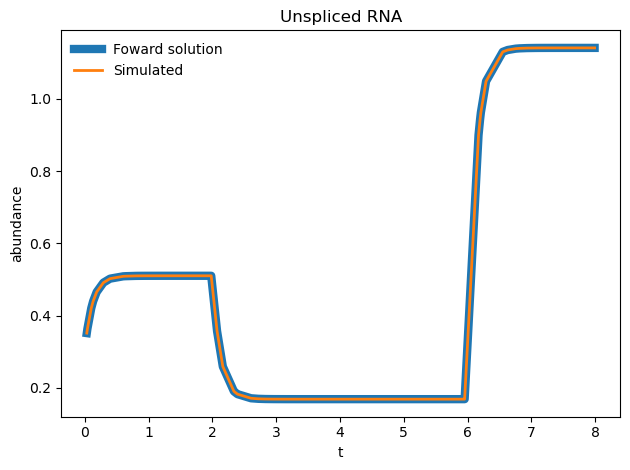

In [32]:
fig, ax = plt.subplots()

ax.plot(t, U, label='Foward solution', linewidth=6)              # thicker line
ax.plot(t, Y[:, gene_idx, 0], label='Simulated', linewidth=2)

ax.set_title("Unspliced RNA")
ax.set_xlabel('t')
ax.set_ylabel('abundance')
ax.legend(frameon=False)
plt.tight_layout()

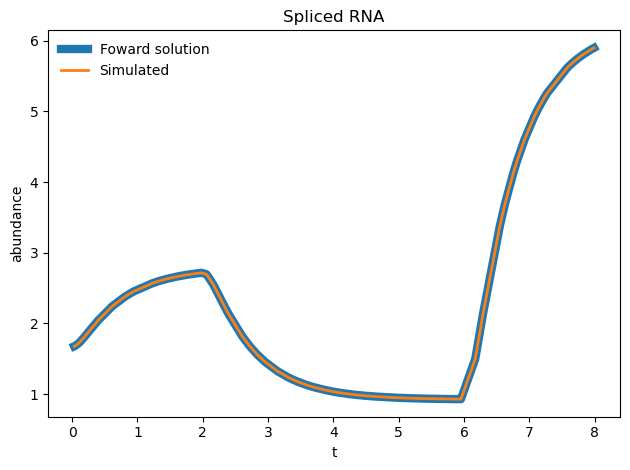

In [33]:
fig, ax = plt.subplots()

ax.plot(t, S, label='Foward solution', linewidth=6)              # thicker line
ax.plot(t, Y[:, gene_idx, 1], label='Simulated', linewidth=2)

ax.set_title("Spliced RNA")
ax.set_xlabel('t')
ax.set_ylabel('abundance')
ax.legend(frameon=False)
plt.tight_layout()

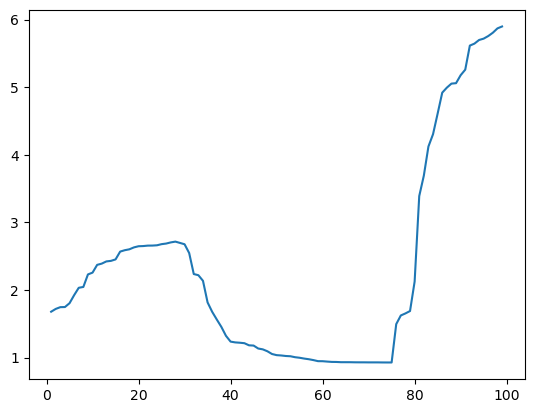

In [22]:
plt.plot(range(start_idx, cell_idx + 1), Y[start_idx:, gene_idx, 1])

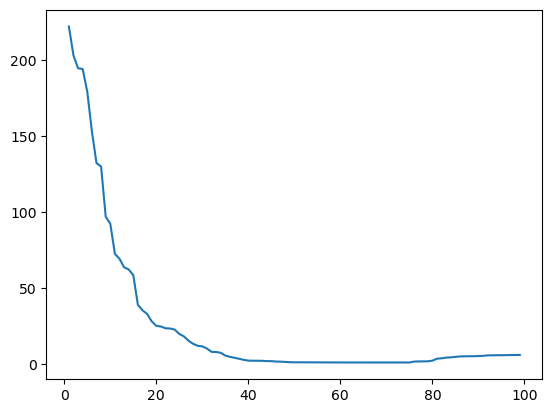

In [23]:
plt.plot(range(start_idx, cell_idx + 1), S[start_idx:])

In [ ]:
from mpmath import mp

In [123]:
import numpy as np
print(np.finfo(np.longdouble))

def estimate_dps(beta, t):
    T = float(t[-1] - t[0])
    return int(np.ceil(beta * T / np.log(10.0))) + 10

Machine parameters for float128
---------------------------------------------------------------
precision =  18   resolution = 1e-18
machep =    -63   eps =        1.084202172485504434e-19
negep =     -64   epsneg =     5.42101086242752217e-20
minexp = -16382   tiny =       3.3621031431120935063e-4932
maxexp =  16384   max =        1.189731495357231765e+4932
nexp =       15   min =        -max
smallest_normal = 3.3621031431120935063e-4932   smallest_subnormal = 4e-4951
---------------------------------------------------------------



In [63]:
import numpy as np

def _cross_term(beta, gamma, dt):
    # C = (e^{-βΔ} - e^{-γΔ}) / (γ - β), with smooth γ≈β limit
    d = gamma - beta
    return np.where(
        np.abs(d) > 0,
        np.exp(-gamma*dt) * (np.expm1(d*dt) / d),   # e^{-γΔ} * (e^{(γ-β)Δ}-1)/(γ-β)
        dt * np.exp(-gamma*dt)
    )

def backward_step(Uk, Sk, alpha, beta, gamma, dt):
    # centered, numerically stable inverses
    a_over_b = alpha / beta
    a_over_g = alpha / gamma
    EB = np.exp(beta * dt)     # backward multiplier for U
    EG = np.exp(gamma * dt)    # backward multiplier for S
    C  = _cross_term(beta, gamma, dt)
    U_prev = a_over_b + (Uk - a_over_b) * EB
    S_prev = a_over_g + EG * (Sk - a_over_g - beta * C * (U_prev - a_over_b))
    return U_prev, S_prev

def forward_step_const_alpha(U_prev, S_prev, alpha, beta, gamma, dt):
    eB = np.exp(-beta*dt); eG = np.exp(-gamma*dt)
    one_minus_eB_over_beta  = -np.expm1(-beta  * dt) / beta
    one_minus_eG_over_gamma = -np.expm1(-gamma * dt) / gamma
    C  = _cross_term(beta, gamma, dt)
    U = eB * U_prev + alpha * one_minus_eB_over_beta
    S = eG * S_prev + beta * C * U_prev + alpha * (one_minus_eG_over_gamma - C)
    return U, S

def backward_pass_timepoint_alpha(U_last, S_last, t, tau, alpha_state, beta, gamma, start_idx=None, atol=1e-12):
    t = np.asarray(t); K = len(tau)-1
    assert alpha_state.shape == (K,), f"alpha_state must be length {K}, got {alpha_state.shape}"

    if start_idx is None: start_idx = len(t)-1

    # Right-closed: τ_j < t_i ≤ τ_{j+1}
    state_grid = np.searchsorted(tau, t, side='right') - 1
    alpha_grid = alpha_state[state_grid]

    U = np.full(len(t), np.nan); S = np.full(len(t), np.nan)
    U[start_idx] = U_last; S[start_idx] = S_last

    for k in range(start_idx, 0, -1):
        t_prev, t_cur = t[k-1], t[k]
        s_prev, s_cur = state_grid[k-1], state_grid[k]

        if s_prev == s_cur:
            U[k-1], S[k-1] = backward_step(U[k], S[k], alpha_grid[k], beta, gamma, t_cur - t_prev)
        else:
            # cross exactly at τ_c
            assert s_cur == s_prev + 1, "multiple boundaries crossed in one step"
            tau_c = tau[s_cur]
            if np.isclose(tau_c, t_prev, atol=atol):
                U[k-1], S[k-1] = backward_step(U[k], S[k], alpha_state[s_cur], beta, gamma, t_cur - t_prev)
            elif np.isclose(tau_c, t_cur, atol=atol):
                U[k-1], S[k-1] = backward_step(U[k], S[k], alpha_state[s_prev], beta, gamma, t_cur - t_prev)
            else:
                U_tau, S_tau   = backward_step(U[k],   S[k],   alpha_state[s_cur],  beta, gamma, t_cur - tau_c)
                U[k-1], S[k-1] = backward_step(U_tau, S_tau, alpha_state[s_prev], beta, gamma, tau_c - t_prev)
    return U, S

def forward_step_interval(U_prev, S_prev, k, t, tau, alpha_state, beta, gamma, atol=1e-12):
    t_prev, t_cur = t[k-1], t[k]
    s_prev = np.searchsorted(tau, t_prev, side='right') - 1
    s_cur  = np.searchsorted(tau, t_cur,  side='right') - 1
    if s_prev == s_cur:
        return forward_step_const_alpha(U_prev, S_prev, alpha_state[s_cur], beta, gamma, t_cur - t_prev)
    tau_c = tau[s_cur]
    if np.isclose(tau_c, t_prev, atol=atol):
        return forward_step_const_alpha(U_prev, S_prev, alpha_state[s_cur], beta, gamma, t_cur - t_prev)
    if np.isclose(tau_c, t_cur, atol=atol):
        return forward_step_const_alpha(U_prev, S_prev, alpha_state[s_prev], beta, gamma, t_cur - t_prev)
    U_mid, S_mid = forward_step_const_alpha(U_prev, S_prev, alpha_state[s_prev], beta, gamma, tau_c - t_prev)
    return forward_step_const_alpha(U_mid, S_mid, alpha_state[s_cur], beta, gamma, t_cur - tau_c)

def first_mismatch(U, S, Y, t, tau, alpha_state, beta, gamma, rtol=1e-11, atol=1e-12):
    # Check recursion against forward map AND simulator means Y at every k
    for k in reversed(range(1, len(t))):
        Uf, Sf = forward_step_interval(U[k-1], S[k-1], k, t, tau, alpha_state, beta, gamma)
        # if not (np.allclose(Uf, U[k], rtol=rtol, atol=atol) and np.allclose(Sf, S[k], rtol=rtol, atol=atol)):
        #     return ("forward/backward mismatch", k, Uf, U[k], Sf, S[k])
        if not (np.allclose(U[k], Y[k, 0], rtol=rtol, atol=atol) and np.allclose(S[k], Y[k, 1], rtol=rtol, atol=atol)):
            return ("vs-simulator mismatch", k, Y[k, 0], U[k], Y[k, 1], S[k])
    return ("ok", None, None, None, None, None)



In [ ]:
# Build per-STATE α (NOT per-timepoint)
K = len(tau) - 1
beta  = float(theta[gene_idx, -2])
gamma = float(theta[gene_idx, -1])
a_over_beta = theta[gene_idx, 1:K+1]     # columns 1..K  (α/β)
alpha_state = a_over_beta * beta          # shape (K,)

# terminal (noise-free) means
idxT = len(time_grid) - 1
U_T = float(Y[idxT, gene_idx, 0])
S_T = float(Y[idxT, gene_idx, 1])

U, S = backward_pass_timepoint_alpha(U_T, S_T, t, tau, alpha_state, beta, gamma, start_idx=idxT)

kind, k, x1, x2, y1, y2 = first_mismatch(U, S, Y[:, gene_idx, :], t, tau, alpha_state, beta, gamma)
print("check:", kind, "at k=", k)
if kind == "ok":
    ok = ~np.isnan(U)
    print("max |ΔU| =", np.max(np.abs(U[ok] - Y[:, gene_idx, 0][ok])),
          "max |ΔS| =", np.max(np.abs(S[ok] - Y[:, gene_idx, 1][ok])))


check: vs-simulator mismatch at k= 91


In [65]:
first_mismatch(U, S, Y[:, gene_idx, :], time_grid, tau, alpha_state, beta, gamma)

('vs-simulator mismatch',
 91,
 np.float64(1.1409471477800635),
 np.float64(1.1409471477800155),
 np.float64(5.260166523495448),
 np.float64(5.260166523388571))

In [ ]:
# import numpy as np

# def closed_form_single_gene(t, tau, a0_over_beta, a_over_beta, beta, gamma):
#     """
#     Exact E[U], E[S] for one gene under piecewise-constant α.
#     - a0_over_beta = alpha0 / beta  (theta[gene, 0])
#     - a_over_beta  = [alpha1/beta, ..., alphaK/beta]  (length K)
#     """
#     t = np.asarray(t)
#     K = len(tau) - 1
#     assert len(a_over_beta) == K

#     eBt = np.exp(-beta * t)
#     eGt = np.exp(-gamma * t)

#     # U(t)
#     U = a0_over_beta * eBt.copy()
#     for k in range(1, K + 1):
#         Ik  = (t > tau[k])                      # t > tau_k
#         idx = (t > tau[k-1]) & (~Ik)            # tau_{k-1} < t <= tau_k
#         ak  = a_over_beta[k-1]                  # alpha_k / beta

#         U += ak * (np.exp(-beta * (t - tau[k])) - np.exp(-beta * (t - tau[k-1]))) * Ik
#         U += ak * (1.0 - np.exp(-beta * (t - tau[k-1]))) * idx

#     # S(t) via same constants used in the simulator
#     c = beta / (beta - gamma)
#     d = (beta**2) / ((beta - gamma) * gamma)
#     S = d * a0_over_beta * eGt.copy()
#     for k in range(1, K + 1):
#         Ik  = (t > tau[k])
#         idx = (t > tau[k-1]) & (~Ik)
#         ak  = a_over_beta[k-1]
#         S  += d * ak * (np.exp(-gamma * (t - tau[k])) - np.exp(-gamma * (t - tau[k-1]))) * Ik
#         S  += d * ak * (1.0 - np.exp(-gamma * (t - tau[k-1]))) * idx

#     S = S - c * U
#     return U, S

# def _cross_term(beta, gamma, dt):
#     # C = (e^{-βΔ} - e^{-γΔ}) / (γ - β), with smooth γ≈β limit
#     d = gamma - beta
#     return np.where(
#         np.abs(d) > 0,
#         np.exp(-gamma*dt) * (np.expm1(d*dt) / d),
#         dt * np.exp(-gamma*dt)
#     )

# def backward_step_centered(Uk, Sk, alpha, beta, gamma, dt):
#     # centered (around α/β and α/γ) to avoid big-minus-big cancellation
#     a_over_b = alpha / beta
#     a_over_g = alpha / gamma
#     EB = np.exp(beta  * dt)          # backward multiplier for U
#     EG = np.exp(gamma * dt)          # backward multiplier for S
#     C  = _cross_term(beta, gamma, dt)

#     U_prev = a_over_b + (Uk - a_over_b) * EB
#     S_prev = a_over_g + EG * (Sk - a_over_g - beta * C * (U_prev - a_over_b))
#     return U_prev, S_prev

# def choose_anchors(t, tau, beta, kappa=10.0):
#     """
#     Return a sorted list of anchor indices:
#       - always include last time index and index 0
#       - include every τ boundary (mapped to the first t >= τ_j)
#       - insert extra anchors so that each block length <= kappa/beta
#     """
#     t = np.asarray(t)
#     M = len(t) - 1
#     dt_max = kappa / float(beta)

#     # Start with taus mapped to time indices (skip tau[0], tau[-1] outside range typically)
#     tau_idxs = []
#     for j in range(1, len(tau)-1):
#         k_tau = int(np.searchsorted(t, tau[j], side='left'))  # first t >= tau_j
#         if 0 <= k_tau <= M:
#             tau_idxs.append(k_tau)

#     anchors = set([0, M] + tau_idxs)

#     # Enforce max block length by dropping extra anchors backward
#     anchors = sorted(anchors)
#     out = [anchors[-1]]
#     for i in range(len(anchors)-1, 0, -1):
#         hi = anchors[i]
#         lo = anchors[i-1]
#         # subdivide [lo, hi] if too long
#         while t[hi] - t[lo] > dt_max:
#             # place an interior anchor at time t[hi] - dt_max
#             target_t = t[hi] - dt_max
#             k = int(np.searchsorted(t, target_t, side='left'))
#             if k <= lo:  # can't go further; break to avoid infinite loop
#                 break
#             out.append(k)
#             hi = k
#         out.append(lo)
#     return sorted(set(out))

# def reanchored_backward(U_T, S_T, t, tau, alpha_state, beta, gamma, kappa=10.0):
#     """
#     Re-anchored backward pass:
#       - alpha_state: per-STATE α, length K (for intervals (τ_j, τ_{j+1}])
#       - Uses right-closed state assignment (τ_j < t_i ≤ τ_{j+1})
#       - Anchors at τ boundaries and interior points so that each block
#         has length <= kappa/beta.
#     """
#     t = np.asarray(t)
#     K = len(tau) - 1
#     assert len(alpha_state) == K

#     # per-timepoint state and α (right-closed)
#     state_grid = np.searchsorted(tau, t, side='right') - 1
#     alpha_grid = alpha_state[state_grid]

#     # closed-form at all times (to re-anchor)
#     a0_over_beta = None  # recover from alpha_state & theta if you have it; else pass explicitly
#     # we can recover a0_over_beta from your theta outside this function and pass it in.
#     # To keep the function self-contained, we'll compute a_over_beta from alpha_state and require a0_over_beta as arg.

#     raise_if_missing = """
#     Please compute a0_over_beta = theta[gene_idx, 0] (that's alpha0/beta in your simulator)
#     and call reanchored_backward_with_a0 below instead (it wraps this function).
#     """
#     return raise_if_missing

# def reanchored_backward_with_theta(U_T, S_T, t, tau, theta_row, kappa=10.0):
#     """
#     theta_row: theta[gene_idx, :] from your simulator
#        layout: [a0_over_beta, a1_over_beta, ..., aK_over_beta, beta, gamma]
#     """
#     K = len(tau) - 1
#     a0_over_beta = float(theta_row[0])
#     a_over_beta  = theta_row[1:K+1].astype(float)
#     beta  = float(theta_row[-2])
#     gamma = float(theta_row[-1])
#     alpha_state = a_over_beta * beta

#     # exact closed form at anchors
#     U_cf, S_cf = closed_form_single_gene(t, tau, a0_over_beta, a_over_beta, beta, gamma)

#     # anchors
#     anchors = choose_anchors(t, tau, beta, kappa=kappa)

#     # prep arrays and state/alpha grids
#     state_grid = np.searchsorted(tau, t, side='right') - 1
#     alpha_grid = alpha_state[state_grid]

#     U = np.full_like(t, np.nan, dtype=float)
#     S = np.full_like(t, np.nan, dtype=float)

#     # Start from the last anchor: force to closed form (ignore U_T,S_T mismatch if any)
#     U[anchors[-1]] = U_cf[anchors[-1]]
#     S[anchors[-1]] = S_cf[anchors[-1]]

#     # walk blocks right → left
#     for i in range(len(anchors)-1, 0, -1):
#         hi = anchors[i]
#         lo = anchors[i-1]

#         # ensure exact anchor at the right boundary
#         U[hi], S[hi] = U_cf[hi], S_cf[hi]

#         # invert within (lo, hi]
#         for k in range(hi, lo, -1):
#             t_prev, t_cur = t[k-1], t[k]
#             s_prev, s_cur = state_grid[k-1], state_grid[k]
#             if s_prev == s_cur:
#                 U[k-1], S[k-1] = backward_step(U[k], S[k], alpha_grid[k], beta, gamma, t_cur - t_prev)
#             else:
#                 # split exactly at τ_c
#                 tau_c = tau[s_cur]
#                 if np.isclose(tau_c, t_prev, atol=1e-12):
#                     U[k-1], S[k-1] = backward_step(U[k], S[k], alpha_state[s_cur], beta, gamma, t_cur - t_prev)
#                 elif np.isclose(tau_c, t_cur, atol=1e-12):
#                     U[k-1], S[k-1] = backward_step(U[k], S[k], alpha_state[s_prev], beta, gamma, t_cur - t_prev)
#                 else:
#                     U_tau, S_tau   = backward_step(U[k], S[k], alpha_state[s_cur],  beta, gamma, t_cur - tau_c)
#                     U[k-1], S[k-1] = backward_step(U_tau, S_tau, alpha_state[s_prev], beta, gamma, tau_c - t_prev)

#         # snap (re-anchor) exactly at the left boundary of the block
#         U[lo], S[lo] = U_cf[lo], S_cf[lo]

#     return U, S, anchors, (U_cf, S_cf)


In [ ]:
# # pick a gene
# g = 4
# theta_row = theta[g, :]          # your simulator's per-gene parameter row

# # terminal (noise-free) means
# idxT = len(true_t) - 1
# U_T, S_T = Y[idxT, g, 0], Y[idxT, g, 1]

# # Run re-anchored backward; set kappa (e.g., 10 ⇒ per-block amp ≤ e^{10} ≈ 22k)
# U_hat, S_hat, anchors, (U_cf, S_cf) = reanchored_backward_with_theta(
#     U_T, S_T, true_t, tau, theta_row, kappa=100
# )

# # Inspect error
# mask = ~np.isnan(U_hat)
# print("max |ΔU| =", np.max(np.abs(U_hat[mask] - Y[:, g, 0][mask])))
# print("max |ΔS| =", np.max(np.abs(S_hat[mask] - Y[:, g, 1][mask])))
# print("anchors (indices):", anchors)


max |ΔU| = 0.037770760573706874
max |ΔS| = 0.046233283124253344
anchors (indices): [0, 29, 76, 99]
